# Face-aware crop and head-fit rejection

`face_aware_crop` (`src/lib/crop.py`) does a resize-to-cover, then biases the
crop toward the joint span of the head-extended face boxes. For portrait
sources rendered onto a landscape target, the face centre lands on the **top
third** of the crop window instead of the middle, so the eyes sit on the
upper-third line where landscape composition reads best.

The display picker now adds a safety rule before accepting a photo: every
head-extended face box, padded by `HEAD_SAFETY_MARGIN`, must fit inside the
crop window. If any head would be cut off, the photo is rejected and another
candidate is fetched instead.

The notebook walks each bundled photo through both target orientations
(800x480 landscape and 480x800 portrait) and shows:

1. Original with face boxes drawn (cyan = required head-fit region, yellow = raw box)
2. Naive centre cover-crop (no face awareness)
3. `face_aware_crop` output, labelled `ACCEPT` or `REJECT`

The pool comes from the bundled CC photos in `photos/`.


In [1]:
import sys

sys.path.insert(0, ".")
from _helpers import (
    PHOTOS_DIR,
    bootstrap,
    center_crop,
    image_faces,
    local_pool,
    open_image,
)

bootstrap()

import matplotlib.pyplot as plt
from crop import HEAD_EXTENSION, HEAD_SAFETY_MARGIN, face_aware_crop, heads_fit_in_crop
from PIL import ImageDraw

LANDSCAPE = (800, 480)
PORTRAIT = (480, 800)

In [2]:
pool = local_pool()
with_faces = [a for a in pool if image_faces(a)]
print(f"pool: {len(pool)} photos, {len(with_faces)} with faces")
for a in with_faces:
    w, h = a["exifInfo"]["exifImageWidth"], a["exifInfo"]["exifImageHeight"]
    orient = "portrait" if h > w else "landscape"
    print(f"  {a['originalFileName']:35s} {w}x{h} ({orient})")

pool: 5 photos, 3 with faces
  man_on_cliff.jpg                    1600x1067 (landscape)
  man_with_dog.jpg                    1600x1067 (landscape)
  mother_and_daughter.jpg             800x1200 (portrait)


In [3]:
def draw_face_boxes(image, faces):
    """Copy of image with face boxes overlaid (cyan = required head region, yellow = raw)."""
    iw, ih = image.size
    canvas = image.copy()
    draw = ImageDraw.Draw(canvas)
    line_w = max(2, min(iw, ih) // 250)
    for f in faces:
        sx = iw / (f.get("imageWidth") or iw)
        sy = ih / (f.get("imageHeight") or ih)
        x1, y1 = f["boundingBoxX1"] * sx, f["boundingBoxY1"] * sy
        x2, y2 = f["boundingBoxX2"] * sx, f["boundingBoxY2"] * sy
        face_w = x2 - x1
        face_h = y2 - y1
        x_margin = face_w * HEAD_SAFETY_MARGIN
        y_margin = face_h * HEAD_SAFETY_MARGIN
        head_y1 = y1 - face_h * HEAD_EXTENSION
        draw.rectangle(
            [x1 - x_margin, head_y1 - y_margin, x2 + x_margin, y2 + y_margin],
            outline=(0, 220, 255),
            width=line_w,
        )
        draw.rectangle([x1, y1, x2, y2], outline=(255, 220, 0), width=line_w)
    return canvas

wrote photos/crop_compare_portrait.png


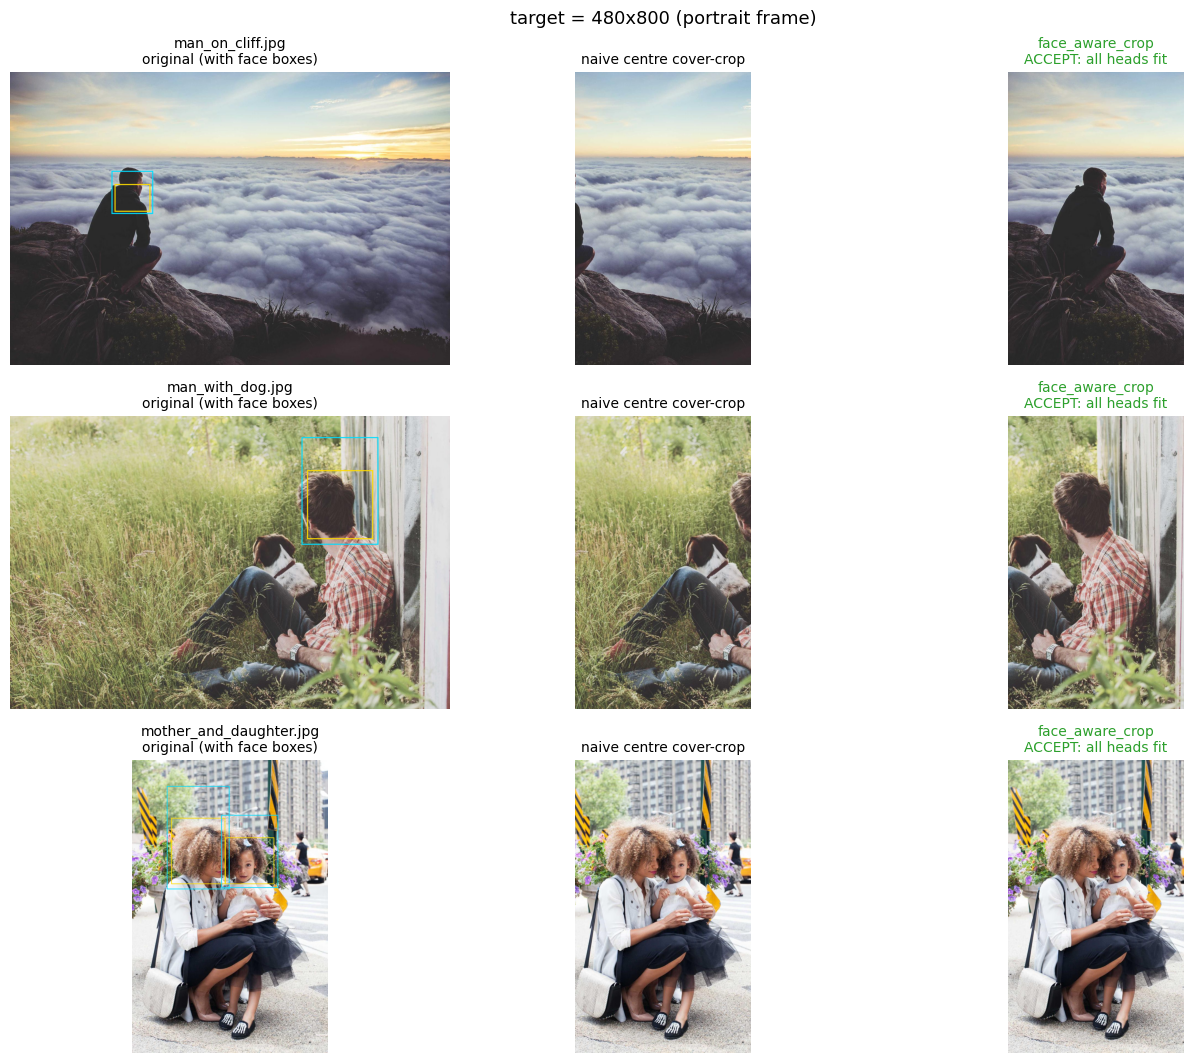

In [4]:
def render_section(target_w, target_h, label, out_name):
    rows = []
    for asset in with_faces:
        img = open_image(asset)
        faces = image_faces(asset)
        annotated = draw_face_boxes(img, faces)
        centre = center_crop(img, target_w, target_h)
        smart = face_aware_crop(img, target_w, target_h, faces)
        fits = heads_fit_in_crop(img, target_w, target_h, faces)
        rows.append((asset["originalFileName"], fits, annotated, centre, smart))

    fig, axes = plt.subplots(len(rows), 3, figsize=(14, 3.6 * len(rows)))
    if len(rows) == 1:
        axes = [axes]
    fig.suptitle(f"target = {target_w}x{target_h} ({label})", fontsize=13)
    titles = ["original (with face boxes)", "naive centre cover-crop", "face_aware_crop"]
    for i, (name, fits, annotated, centre, smart) in enumerate(rows):
        for j, (img_panel, base_title) in enumerate(
            zip([annotated, centre, smart], titles, strict=True)
        ):
            ax = axes[i][j]
            ax.imshow(img_panel)
            if j == 0:
                title = f"{name}\n{base_title}"
                color = "black"
            elif j == 2:
                status = "ACCEPT: all heads fit" if fits else "REJECT: head safety box is cropped"
                title = f"{base_title}\n{status}"
                color = "tab:green" if fits else "tab:red"
            else:
                title = base_title
                color = "black"
            ax.set_title(title, fontsize=10, color=color)
            ax.axis("off")
    plt.tight_layout()
    out_path = PHOTOS_DIR / out_name
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    print(f"wrote {out_path.relative_to(PHOTOS_DIR.parent)}")
    plt.show()

render_section(*PORTRAIT, "portrait frame", "crop_compare_portrait.png")

## Reading the comparison

- **Cyan boxes** are the required head-fit regions: the raw face boxes are
  extended upward by `HEAD_EXTENSION` to cover the top of the head, then padded
  by `HEAD_SAFETY_MARGIN` on all sides.
- **Yellow boxes** are the raw bounding boxes from the source.
- For portrait sources on a landscape target, the face centre sits at the
  **top third** of the crop window, not the middle. That keeps the eyes on
  the upper-third line and leaves room for the body below.
- `ACCEPT` means the same crop would be eligible for display. `REJECT` means
  the picker would discard that photo for that target orientation and try
  another candidate without writing it to display history.
- The naive centre cover-crop column shows what you'd get without face
  awareness. It's the worst case, the column to compare against.
